Dataset berhasil didownload
File berhasil diekstrak

===== DATASET AWAL =====
         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  

Jumlah data setelah cleaning : 2049280

Jumlah sam

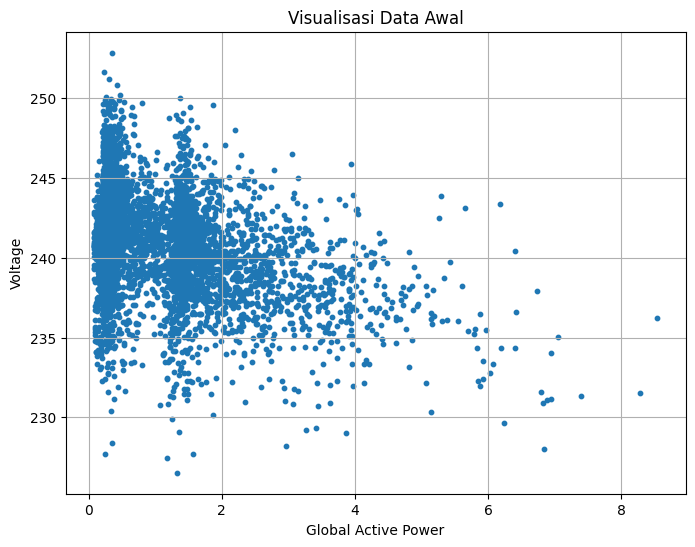


===== ELBOW METHOD =====
K = 1 | Inertia = 15000.000000000056
K = 2 | Inertia = 7950.567612138602
K = 3 | Inertia = 5411.946027100781
K = 4 | Inertia = 4118.352444114658
K = 5 | Inertia = 3362.8367385942825
K = 6 | Inertia = 2733.951164857482
K = 7 | Inertia = 2334.1400931888784
K = 8 | Inertia = 2057.589283058701
K = 9 | Inertia = 1809.7469564083726
K = 10 | Inertia = 1598.1842504955484


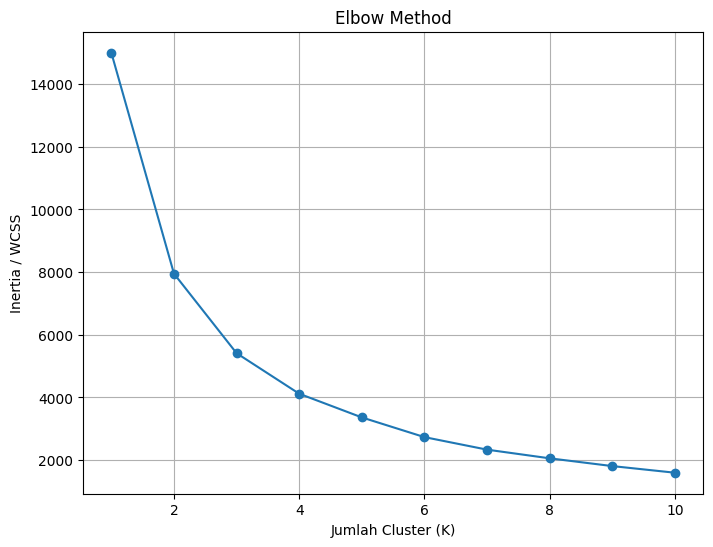


===== SILHOUETTE SCORE =====
K = 2 | Silhouette Score = 0.5071899043169622
K = 3 | Silhouette Score = 0.4261125975981839
K = 4 | Silhouette Score = 0.380791565972179
K = 5 | Silhouette Score = 0.4005388890272881
K = 6 | Silhouette Score = 0.40701986367392085
K = 7 | Silhouette Score = 0.40570435108875424
K = 8 | Silhouette Score = 0.40864236198347187
K = 9 | Silhouette Score = 0.38775960751489774
K = 10 | Silhouette Score = 0.3962629888900946


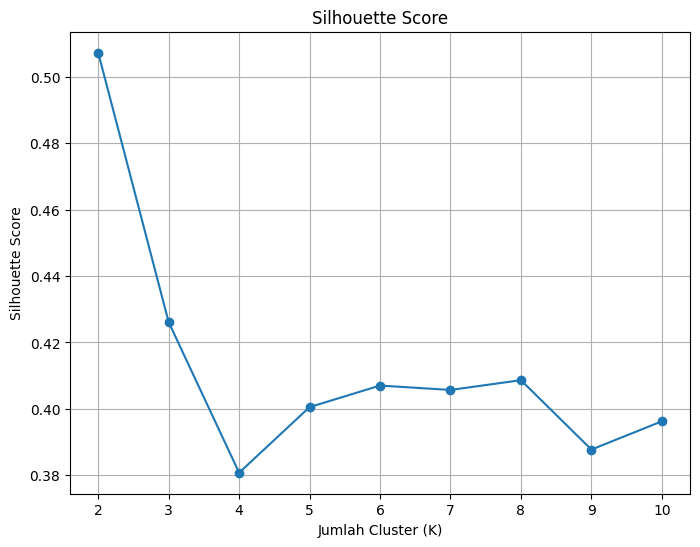


K terbaik berdasarkan silhouette score = 2

===== HASIL CLUSTER =====
         Global_active_power  Voltage  Global_intensity  Cluster
1030580                1.502   240.17               6.4        1
1815                   0.374   245.50               1.8        1
1295977                0.620   239.85               3.0        1
206669                 0.280   235.72               1.4        1
1048893                1.372   243.95               5.6        1

===== CENTROID =====
[[ 1.49113325 -0.93393313  1.49675385]
 [-0.39399096  0.24676615 -0.39547605]]


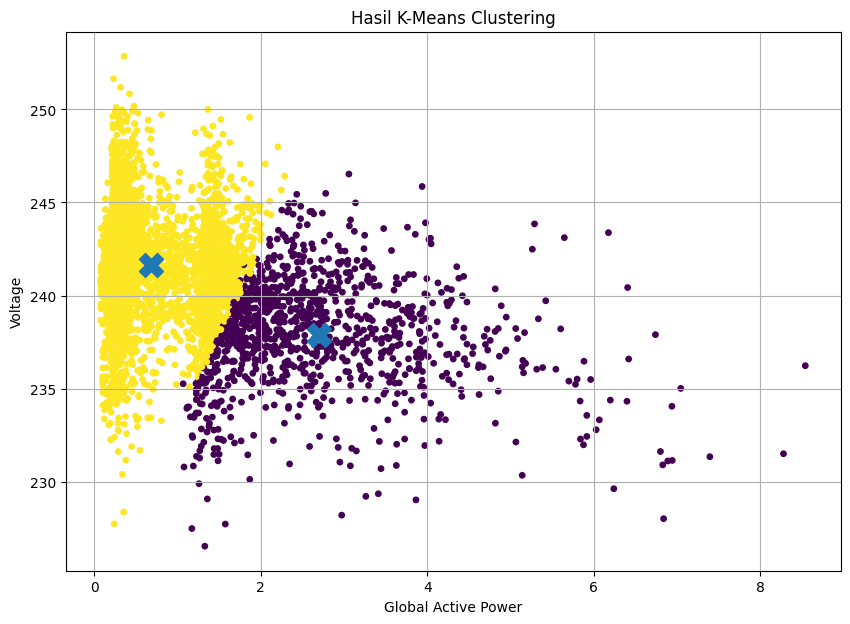


===== JUMLAH DATA PER CLUSTER =====
Cluster
1    3954
0    1046
Name: count, dtype: int64

===== RATA-RATA TIAP CLUSTER =====
         Global_active_power     Voltage  Global_intensity
Cluster                                                   
0                   2.701562  237.885296         11.416826
1                   0.679474  241.665792          2.889176

Hasil clustering berhasil disimpan
Nama file : hasil_kmeans_household_power.csv

Program selesai dijalankan


In [1]:
# ============================================================
# K-MEANS CLUSTERING
# DATASET : HOUSEHOLD POWER CONSUMPTION
# + ELBOW METHOD
# + SILHOUETTE SCORE
# + VISUALISASI CLUSTER
# ============================================================

# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from urllib.request import urlretrieve
from zipfile import ZipFile

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ============================================================
# DOWNLOAD DATASET
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"

urlretrieve(url, "household_power_consumption.zip")

print("Dataset berhasil didownload")

# ============================================================
# EXTRACT FILE ZIP
# ============================================================

with ZipFile("household_power_consumption.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("File berhasil diekstrak")

# ============================================================
# MEMBACA DATASET
# ============================================================

DF = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False
)

print("\n===== DATASET AWAL =====")
print(DF.head())

# ============================================================
# MENGUBAH TIPE DATA
# ============================================================

kolom_numerik = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for kolom in kolom_numerik:
    DF[kolom] = pd.to_numeric(DF[kolom], errors='coerce')

# ============================================================
# MENGHAPUS MISSING VALUE
# ============================================================

DF = DF.dropna()

print("\nJumlah data setelah cleaning :", len(DF))

# ============================================================
# MENGAMBIL SAMPLE
# (AGAR KOMPUTASI LEBIH CEPAT)
# ============================================================

DF = DF.sample(
    n=5000,
    random_state=42
)

print("\nJumlah sample :", len(DF))

# ============================================================
# MEMILIH FITUR
# ============================================================

FITUR = [
    'Global_active_power',
    'Voltage',
    'Global_intensity'
]

X = DF[FITUR]

print("\n===== FITUR YANG DIGUNAKAN =====")
print(X.head())

# ============================================================
# NORMALISASI DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# VISUALISASI DATA AWAL
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    X['Global_active_power'],
    X['Voltage'],
    s=10
)

plt.title('Visualisasi Data Awal')
plt.xlabel('Global Active Power')
plt.ylabel('Voltage')
plt.grid(True)

plt.show()

# ============================================================
# ELBOW METHOD
# ============================================================

print("\n===== ELBOW METHOD =====")

inertia_values = []

K_range = range(1, 11)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia_values.append(model.inertia_)

    print(f"K = {k} | Inertia = {model.inertia_}")

# ============================================================
# VISUALISASI ELBOW
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    K_range,
    inertia_values,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia / WCSS')
plt.grid(True)

plt.show()

# ============================================================
# SILHOUETTE SCORE
# ============================================================

print("\n===== SILHOUETTE SCORE =====")

silhouette_scores = []

K_range_silhouette = range(2, 11)

for k in K_range_silhouette:

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k} | Silhouette Score = {score}")

# ============================================================
# VISUALISASI SILHOUETTE SCORE
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    K_range_silhouette,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.show()

# ============================================================
# MENENTUKAN K TERBAIK
# ============================================================

best_k = K_range_silhouette[
    np.argmax(silhouette_scores)
]

print("\nK terbaik berdasarkan silhouette score =", best_k)

# ============================================================
# MODEL FINAL K-MEANS
# ============================================================

model_final = KMeans(
    n_clusters=best_k,
    init='k-means++',
    random_state=42,
    n_init=10
)

labels = model_final.fit_predict(X_scaled)

# ============================================================
# MENAMBAHKAN LABEL CLUSTER
# ============================================================

DF['Cluster'] = labels

print("\n===== HASIL CLUSTER =====")
print(DF[['Global_active_power',
          'Voltage',
          'Global_intensity',
          'Cluster']].head())

# ============================================================
# CENTROID
# ============================================================

centroids = model_final.cluster_centers_

print("\n===== CENTROID =====")
print(centroids)

# ============================================================
# VISUALISASI HASIL CLUSTERING
# ============================================================

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    DF['Global_active_power'],
    DF['Voltage'],
    c=labels,
    s=15
)

# ============================================================
# VISUALISASI CENTROID
# ============================================================

centroid_asli = scaler.inverse_transform(centroids)

plt.scatter(
    centroid_asli[:,0],
    centroid_asli[:,1],
    marker='X',
    s=300
)

plt.title('Hasil K-Means Clustering')
plt.xlabel('Global Active Power')
plt.ylabel('Voltage')
plt.grid(True)

plt.show()

# ============================================================
# JUMLAH DATA PER CLUSTER
# ============================================================

print("\n===== JUMLAH DATA PER CLUSTER =====")
print(DF['Cluster'].value_counts())

# ============================================================
# RATA-RATA TIAP CLUSTER
# ============================================================

print("\n===== RATA-RATA TIAP CLUSTER =====")

print(
    DF.groupby('Cluster')[FITUR].mean()
)

# ============================================================
# SIMPAN HASIL
# ============================================================

DF.to_csv(
    "hasil_kmeans_household_power.csv",
    index=False
)

print("\nHasil clustering berhasil disimpan")
print("Nama file : hasil_kmeans_household_power.csv")

# ============================================================
# SELESAI
# ============================================================

print("\nProgram selesai dijalankan")